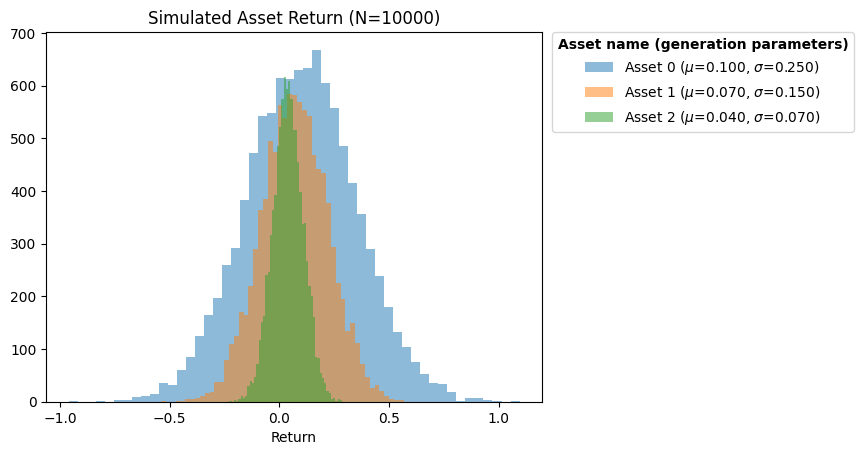

In [41]:
import numpy as np
import matplotlib.pyplot as plt 
from scipy.stats import skew
import pandas as pd

class DataGeneration():
    def __init__(self, mus=[], sigmas=[], rho=[] , asset_names=None):
        self.mus    = np.array(mus, dtype=float) 
        self.sigmas = np.array(sigmas, dtype=float) 
        self.rho    = np.array(rho, dtype=float)
        D = np.diag(self.sigmas)
        self.covariance = D @ self.rho @ D 
        
        n_assets = self.mus.shape[0]
        self.asset_names =  (asset_names if asset_names is not None \
                            else [f"Asset {i}" for i in range(n_assets)]
        )
        self.Rt = None
    
    def generate(self, T, seed=None):
        if seed is not None:
            np.random.seed(seed)
        self.Rt =  np.random.multivariate_normal( self.mus, self.covariance, size=T)
        return self.Rt 
    
    def plot(self, bins=50,filename=None):
        if self.Rt is None: 
            raise RuntimeError("Generate returns before calling plot()")
        n_sim = self.Rt.shape[0]
        
        fig, ax = plt.subplots()

        for i, asset in enumerate(self.asset_names):
            ax.hist(self.Rt[:,i], bins=bins, alpha=0.5, label=fr"{asset} ($\mu$={self.mus[i]:.3f}, $\sigma$={self.sigmas[i]:.3f})")
        ax.set_xlabel("Return")
        leg = ax.legend(
            title="Asset name (generation parameters)",
            loc="upper left",
            bbox_to_anchor=(1.02, 1.0),
            borderaxespad=0)
        leg.get_title().set_fontweight("bold")

        ax.set_title(f"Simulated Asset Return (N={n_sim})")

        if filename is not None:
            fig.savefig(filename, format="png", dpi=150, bbox_inches="tight")
        plt.show()
    
    def summary(self):
        if self.Rt is None: 
            raise RuntimeError("Generate returns before calling summary()")
        #quantiles
        q_low, q_high  = np.percentile(self.Rt, [15.9, 84.1], axis=0)

        results = {
            "mean":   np.mean(self.Rt, axis=0),
            "std":    np.std(self.Rt, axis=0),
            "median": np.median(self.Rt, axis=0),
            "q15.9":  q_low,
            "q84.1":  q_high,
            "skew":   skew(self.Rt, axis=0),
        }
        correlations = np.corrcoef(self.Rt, rowvar=False)
        df_stats = pd.DataFrame(results, index=self.asset_names)
        df_corr  = pd.DataFrame( correlations , index=self.asset_names, columns=self.asset_names)
        return df_stats, df_corr


mus = [0.10, 0.07, 0.04]
sigmas = [0.25, 0.15, 0.07]
rho = [
    [1.0, 0.6, 0.2],
    [0.6, 1.0, 0.3],
    [0.2, 0.3, 1.0]
]

gen = DataGeneration(mus, sigmas, rho)
returns = gen.generate(T=10_000, seed=42)
results_stat, results_corr = gen.summary()
results_corr
gen.plot(filename="SimulatedAssetReturn.png")
